# XGBoost — loan default (preprocessing + training)

**Dataset:** `data/raw/Train_Dataset.csv`  
**Target:** `Default`

**Mixed-type columns:** Kaggle CSVs often have `object` columns with both numbers and strings. This notebook uses `low_memory=False` on read and coerces categorical columns to strings before `OneHotEncoder`.

Pipeline: `CastCategoricalToString` → impute/scale/OHE → variance filter → MI selection → XGBoost (`models/xgboost/preprocessing_pipeline.py`).

Run **Restart Kernel & Run All** after pulling code changes.

## 1. Paths, imports, reload pipeline module

In [14]:
from pathlib import Path
import importlib
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
%matplotlib inline


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "data" / "raw" / "Train_Dataset.csv").is_file():
            return base
    raise FileNotFoundError("Could not find data/raw/Train_Dataset.csv")


PROJECT_ROOT = find_project_root()
_pp_path = str(PROJECT_ROOT / "models" / "xgboost")
if _pp_path not in sys.path:
    sys.path.insert(0, _pp_path)

import preprocessing_pipeline as pp

importlib.reload(pp)

build_xgb_pipeline = pp.build_xgb_pipeline
feature_importance_series = pp.feature_importance_series

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT


## 2. Config

In [15]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Train_Dataset.csv"
TARGET_COL = "Default"
RANDOM_STATE = 42
TEST_SIZE = 0.2
SELECT_PERCENTILE = 40.0

OUT_MODEL = PROJECT_ROOT / "outputs" / "xgboost" / "trained_models" / "xgboost_notebook.joblib"
OUT_METRICS = PROJECT_ROOT / "outputs" / "xgboost" / "metrics" / "xgboost_notebook.txt"

print("DATA_PATH:", DATA_PATH)

DATA_PATH: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\data\raw\Train_Dataset.csv


## 3. Load data (`low_memory=False` avoids mixed-type column chunks)

In [16]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
if TARGET_COL not in df.columns:
    raise ValueError(f"Missing {TARGET_COL}")
df.head()

Shape: (121856, 40)


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655054,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631354537,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355638717,0.2021,674.0,1.0,0


## 4. Quick EDA

In [17]:
print(df[TARGET_COL].value_counts())
print("\nMissing (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))

Default
0    112011
1      9845
Name: count, dtype: int64

Missing (top 10):
 Own_House_Age                 80095
Score_Source_1                68835
Social_Circle_Default         61928
Client_Occupation             41435
Score_Source_3                26921
Credit_Bureau                 18540
ID_Days                        5968
Score_Source_2                 5686
Population_Region_Relative     4857
Loan_Annuity                   4812
dtype: int64


## 5. Features + target — fix mixed types before sklearn

Coerce every **object** / **category** cell to `str` (leave NaN for imputation). This prevents `OneHotEncoder` errors like *uniformly strings or numbers*.

In [18]:
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

_cat_cols = X.select_dtypes(include=["object", "category"]).columns
for c in _cat_cols:
    X[c] = X[c].map(lambda v: v if pd.isna(v) else str(v))

print("Coerced object/category columns:", len(_cat_cols))

Coerced object/category columns: 20


## 6. Train / test split

In [19]:
def stratify_or_none(ys: pd.Series):
    if ys.nunique() < 2:
        return None
    if ys.value_counts().min() < 2:
        return None
    return ys


strat = stratify_or_none(y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat,
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (97484, 39) Test: (24372, 39)


## 7. Build pipeline and fit

In [20]:
model = build_xgb_pipeline(X_train, select_percentile=SELECT_PERCENTILE)
model

,steps,"[('cast_categorical', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,1.0
,n_jobs,1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
%%time
model.fit(X_train, y_train)

CPU times: total: 1min 1s
Wall time: 5.7 s


,steps,"[('cast_categorical', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,1.0
,n_jobs,1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 8. Evaluation

In [22]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))
try:
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"ROC-AUC: {auc:.4f}")
except Exception as e:
    print("ROC-AUC:", e)

Test accuracy: 0.9197
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     22403
           1       0.69      0.01      0.02      1969

    accuracy                           0.92     24372
   macro avg       0.80      0.50      0.49     24372
weighted avg       0.90      0.92      0.88     24372

ROC-AUC: 0.7223


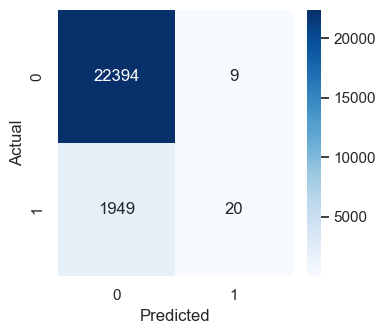

In [23]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Feature importance

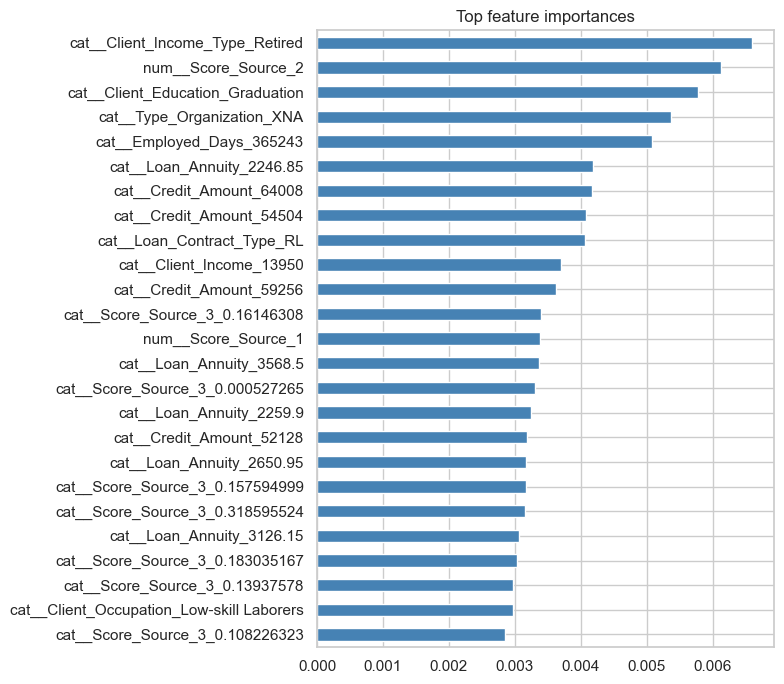

cat__Client_Income_Type_Retired              0.006601
num__Score_Source_2                          0.006120
cat__Client_Education_Graduation             0.005772
cat__Type_Organization_XNA                   0.005374
cat__Employed_Days_365243                    0.005073
cat__Loan_Annuity_2246.85                    0.004181
cat__Credit_Amount_64008                     0.004165
cat__Credit_Amount_54504                     0.004073
cat__Loan_Contract_Type_RL                   0.004065
cat__Client_Income_13950                     0.003693
cat__Credit_Amount_59256                     0.003624
cat__Score_Source_3_0.16146308               0.003401
num__Score_Source_1                          0.003388
cat__Loan_Annuity_3568.5                     0.003367
cat__Score_Source_3_0.000527265              0.003305
cat__Loan_Annuity_2259.9                     0.003250
cat__Credit_Amount_52128                     0.003187
cat__Loan_Annuity_2650.95                    0.003165
cat__Score_Source_3_0.157594

In [24]:
imp = feature_importance_series(model).head(25)
fig, ax = plt.subplots(figsize=(8, 7))
imp.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top feature importances")
plt.tight_layout()
plt.show()
imp

## 10. Save (optional)

In [25]:
OUT_MODEL.parent.mkdir(parents=True, exist_ok=True)
OUT_METRICS.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, OUT_MODEL)
OUT_METRICS.write_text(
    f"accuracy={acc:.4f}\n\n" + classification_report(y_test, y_pred, zero_division=0),
    encoding="utf-8",
)
print("Saved:", OUT_MODEL)
print("Saved:", OUT_METRICS)

Saved: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\outputs\xgboost\trained_models\xgboost_notebook.joblib
Saved: C:\Users\thaks\Y4S2\ML\ML-ASSIGNMENT\outputs\xgboost\metrics\xgboost_notebook.txt
